## Learning Objectives

- Fundmentals of Generative AI Application development using MlFlow

# Project:  Support Ticket Classification Using Large Language Models (LLMs)

## Business Problem
 A rapidly growing SaaS provider specializing in project management solutions, is facing challenges with its customer support ticket management system. The current system uses programmatic keyword-based classification to categorize customer tickets into four types:
  - Incident (urgent issues like payment processing errors),
  - Request (inquiries about pricing, plans, or integrations),
  - Problem (recurring or systemic issues requiring deeper analysis) and
  - Change (requests for updates to billing or account details).
  
  However, this keyword-based approach often fails to capture the nuanced intent of customer messages, leading to frequent misclassifications, delayed resolutions, and dissatisfied customers.Below are two examples highlighting the issue.
   - A customer reported, "I was charged twice for my subscription, and my bank confirms it’s not their error." The system flagged this as a Request due to the word "subscription," but it was an urgent Incident needing immediate refund processing. The 18-hour delay in resolution prompted the customer to post a complaint on social media, damaging the company's reputation.
 - A customer asked, "Can you provide details on payment options for JIRA integration?" The system misclassified this as a Problem because of "payment," routing it to a technical team instead of a support agent. This wasted 10 hours of resources and frustrated the customer, who expected a quick response.
These misclassifications contribute to a 25% error rate in ticket categorization, with urgent Incidents often taking over 20 hours to resolve. This inefficiency increases operational costs, overwhelms support teams, and erodes customer trust, as seen in negative feedback.

## Problem Statement
To address the above challenges, the company proposes deploying a Large Language Model (LLM)-based Support Ticket Classification System to replace the keyword-based approach. The system will leverage the advanced natural language understanding of LLMs to accurately classify tickets into Incident, Request, Problem, or Change categories by analysing the semantic context of customer messages.

## Dataset  
The datasets (for building a classification model using LLMs),  comprising examples and **gold** examples, have been provided under the dataset folder.

## Solution Demo 

## Traditional GenAI  App Development Approach

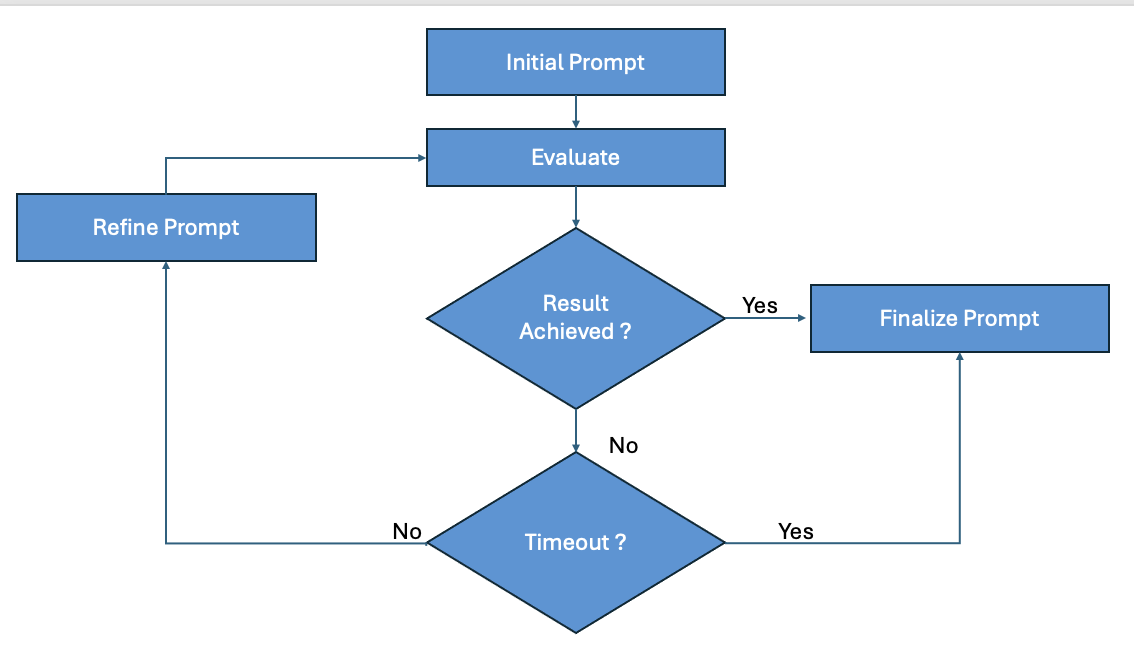

#### Imports

In [1]:
# Standard Library
import json
import os
from typing import Dict, Any, Optional
import numpy as np

#  Data Science & MLimport numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# MLflow GenAI
import mlflow
from mlflow.genai.scorers import scorer

# LLM Clients  
from groq import Groq
from openai import OpenAI
#from google import genai

# Optional
# from google.colab import userdata

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


### LLM Setup

We will be using open source Llama model  using Groq API key.
You can Sign up at console.groq.com (https://console.groq.com/keys) and create a free API key ( email required)

In [2]:
# Configure the Generative AI model

## groc
# groq_api_key = os.getenv('GROQ_API_KEY')
# client = Groq(api_key=groq_api_key)
# MODEL_NAME = "llama-3.1-8b-instant"

# gemini
#gemini_api_key = userdata.get('GEMINI_API_KEY')
#client = genai.Client( api_key=gemini_api_key)
# MODEL_NAME = 

# openai
openai_api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=openai_api_key)
MODEL_NAME= "gpt-4o"

## Dataset Load

Human feedback dataset - golden records

In [3]:
support_ticket_categories_gold_examples_df = pd.read_csv('../dataset/support_ticket_categories_gold_examples.csv')
support_ticket_categories_gold_examples_df.head()

,customer_message,type
0,"Hello, I am writing to inquire about the billi...",Request
1,I am interested in learning more about the Saa...,Request
2,Could you provide additional details on the in...,Request
3,Can you provide information on the billing pro...,Request
4,Seeking details on pricing tiers and billing o...,Request




### Initial Prompt Drafting

Let us assemble a naive zero-shot prompt and evaluate it.

In [4]:
#support_categorization_system_prompt_v1
prompt_v1 = """
Classify customer support messages into one of these categories:
1) "Incident" - Unexpected issue requiring immediate attention
2) "Request" - Routine inquiry or service request
3) "Problem" - Underlying issue causing multiple incidents
4) "Change" - Planned change or update

"""

Let us pass the  customer query (user input) and check the response  

In [7]:
system_message_v1 = [{'role': 'system', 'content': prompt_v1}]

customer_message ="I was charged twice for my subscription, and my bank confirms it’s not their error"

user_message = [{'role':'user',
               'content': customer_message}]

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages= system_message_v1 + user_message ,
    temperature=0,
    max_tokens=128
)

print(response.choices[0].message.content)

1) "Incident" - Unexpected issue requiring immediate attention


### Evaluate

To evaluate this prompt (and all subsequent iterations), we will measure **accuracy** of the prompt over the set of gold examples.

*Gold examples are inputs for evaluation where ground truth is available; predictions from the LLM for these inputs are compared with the ground truths.*

In [6]:
def compute_accuracy_score(prompt, gold_examples_df, model_name=MODEL_NAME):
    """Computes the Accuracy score of an LLM's predictions on a set of gold examples.

    This function evaluates the performance of a prompt by comparing the LLM's
    predictions against the true labels of a set of gold examples. It calculates
    the simple accuracy (percentage of correct predictions).

    Args:
        prompt (list): The prompt to be used for the LLM, formatted as a list of
                       dictionaries with 'role' (as 'system') and 'content' keys.
        gold_examples_df (pd.DataFrame): A pandas DataFrame containing the gold examples,
                                          where each row represents an example with
                                          the customer message in the first column and
                                          the ticket type in the second column.
        model_name (str): The name of the model (LLM) to be used for making predictions.

    Returns:
        float: The Accuracy score of the LLM's predictions (between 0.0 and 1.0).
    """
    # Initialize lists to store predictions and true labels
    predictions, ground_truths = [], []

    # Iterate through each gold example using tqdm for progress visualization
    for index, row in tqdm(gold_examples_df.iterrows(), total=gold_examples_df.shape[0]):
        gold_customer_message = row.iloc[0]   # Extract the customer message text
        gold_label = row.iloc[1]    # Extract the true ticket type label

        # Format user input as a list of dictionaries for the 'messages' parameter
        current_user_message = [{'role': 'user', 'content': gold_customer_message}]

        try:
            # Send the prompt and review to the LLM and get the response
            completion = client.chat.completions.create(
                model=model_name,
                messages=prompt + current_user_message,
                temperature=0,          # Set temperature to 0 for consistent classification
                max_tokens=512
            )

            # Append the LLM's prediction and true label
            predictions.append(completion.choices[0].message.content.strip())
            ground_truths.append(gold_label)

        except Exception as e:
            print(f"Error processing example: {e}")  # Log any errors
            continue  # Skip to the next example

    # Convert to NumPy arrays for scikit-learn metrics
    predictions = np.array(predictions)
    ground_truths = np.array(ground_truths)

    # Calculate and return the accuracy score
    return accuracy_score(ground_truths, predictions)

In [8]:
compute_accuracy_score(system_message_v1, support_ticket_categories_gold_examples_df)

100%|██████████| 64/64 [00:45<00:00,  1.39it/s]


0.0

Above, the zero-shot prompting achieves suboptimal F1-score, indicating the need for prompt refinement and/or few-shot examples.

### Refine Prompt - version 2 :Structured promt
Let us now refine the zero-shot prompt so that its score shall be improved by following prompt engineering best practices i.e. adopting a role and providing clear instructions.

In [11]:
# Self
prompt_v2 = """

[Role]
You are an enterprise-grade ticket classification engine.

[Objective]
Classify customer support messages into one of these categories based on their content and intent:

1) Incident: Unexpected technical or billing issue requiring immediate resolution.
    <Elaborate>

2) Request: Inquiry about products/services or standard information needs.
   <Elaborate>


3) Problem: Recurring or systemic issue causing multiple incidents.
   <Elaborate>

4) Change: Modification to existing account or service configuration.
   <Elaborate>

[Instructions]:
  
    Analyze the message context and intent thoroughly.

    Choose the single most appropriate category.

    Do not guess; if the message is unclear, select the category that best fits the predominant theme.

    Respond ONLY with the category name (Incident, Request, Problem, or Change).

    Do not explain your reasoning.

[Output Format]:
 Only one of the following category names: "Incident", "Request", "Problem", or "Change".


   """

In [12]:
system_message_v2 = [{'role': 'system', 'content': prompt_v2}]

customer_message ="I was charged twice for my subscription, and my bank confirms it’s not their error"

user_message = [{'role':'user',
               'content': customer_message}]

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages= system_message_v2 + user_message ,
    temperature=0,
    max_tokens=128
)

print(response.choices[0].message.content)

Incident


In [ ]:
# Evaluate

compute_accuracy_score(system_message_v2, support_ticket_categories_gold_examples_df)

100%|██████████| 64/64 [00:50<00:00,  1.27it/s]


0.6875

This version of the zero-shot prompt now demonstrates slightly better F1-score, though the score is still very low.

### Refine Prompt :  version 3  : Few-shot Prompts

In [11]:
# one-shot
for index, row in  support_ticket_categories_gold_examples_df.iterrows():
    print('Example Review:')
    print(row.iloc[0])
    print('Example Label:')
    print(row.iloc[1])
    break

Example Review:
Hello, I am writing to inquire about the billing structure for the project management SaaS service. Could you provide more details on the pricing plans and any additional costs associated with the service? I would greatly appreciate information on any discounts available for long-term commitments or large teams. Additionally, it would be helpful to know about the setup fees and cancellation fees. Looking forward to hearing back from you with this information.
Example Label:
Request


In [ ]:
# ToDO
promt_v3 = """

Examples:

   """
few_shot_system_message_v3 = [{'role': 'system', 'content': promt_v3}]
compute_accuracy_score(few_shot_system_message_v3, support_ticket_categories_gold_examples_df)

 56%|█████▋    | 36/64 [02:36<01:37,  3.48s/it]

### Final Selected model

The  prompt, having demonstrated the highest performance against the gold standard examples, is selected as the final version for implementation.

## Problem With Traditional method

- Manual prompt
- Version tracking


# MLflow Approach

In [ ]:
# # for fresh demo delete the previous template first
# from mlflow import MlflowClient
# client = MlflowClient(tracking_uri="http://127.0.0.1:5000")
# # prompt_name = "support-ticket-classifier-prompt"
# # client.delete_prompt(prompt_name)
# exp = client.get_experiment_by_name("Support_Ticket_Classification_project")
# client.delete_experiment(exp.experiment_id)
 

In [9]:
#!pip install mlflow==3.10.0
import mlflow
print(mlflow.__version__)

3.10.1


### Start : MLflow Server

```
mlflow server --port 5000
```
Above command starts the server with default behavior, using a SQLite database as the backend store and local file storage for artifacts..


or explicitly specify or customize the parameters

```
mlflow server \
  --backend-store-uri sqlite:///experiments/mlflow.db \
  --default-artifact-root ./experiments/mlruns \
  --host 127.0.0.1 --port 5000

```
Or, in case of external storage

```
mlflow server \
  --backend-store-uri sqlite:///experiments/mlflow.db \
  --default-artifact-root ./experiments/mlruns \
  --host 127.0.0.1 \
  --port 5000

```



In [ ]:
# ! mlflow server \
#   --backend-store-uri sqlite:///experiments/mlflow.db \
#   --default-artifact-root ./experiments/mlruns \
#   --host 127.0.0.1 --port 5000

## MLflow Setup

In [13]:
# connect to MLflow server
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

# creates/selects an experiment - "Support_Ticket_Classification_project"
mlflow.set_experiment("Support_Ticket_Classification_project")

# to Enable automatic tracing for all OpenAI API calls.
#mlflow.openai.autolog()

2026/03/30 16:21:34 INFO mlflow.tracking.fluent: Experiment with name 'Support_Ticket_Classification_project' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/kaustuvkunal/Learning/GenerativeAI/MLFlow-tutorial/genai-support-ticket-classifier-mlflow-demo/mlruns/artifacts/1', creation_time=1774867894131, experiment_id='1', last_update_time=1774867894131, lifecycle_stage='active', name='Support_Ticket_Classification_project', tags={}, workspace='default'>

## Create & Register a Prompt

In [14]:
initial_template = """
1) "Incident" - Unexpected issue requiring immediate attention
2) "Request" - Routine inquiry or service request
3) "Problem" - Underlying issue causing multiple incidents
4) "Change" - Planned change or update

Respond ONLY with the category name - Incident, Request, Problem, or Change 
"""


# Register a new prompt
prompt = mlflow.genai.register_prompt(
    name="support-ticket-classifier-prompt",
    template=initial_template,
    # Optional: Provide a commit message to describe the changes
    commit_message="Initial commit",
)

# The prompt object contains information about the registered prompt
print(f"Created prompt '{prompt.name}' (version {prompt.version})")

2026/03/30 16:34:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for prompt version to finish creation. Prompt name: support-ticket-classifier-prompt, version 1


Created prompt 'support-ticket-classifier-prompt' (version 1)


## Evaluate


### Evaluation Data Prepration

In [17]:
eval_dataset = pd.DataFrame(
    [
        {
            "inputs": {
                "customer_message": row["customer_message"],
            },
            "expectations": {
                "type": row["type"],
            },
        }
        for _, row in support_ticket_categories_gold_examples_df.iterrows()
    ]
)

eval_dataset

,inputs,expectations
0,"{'customer_message': 'Hello, I am writing to i...",{'type': 'Request'}
1,{'customer_message': 'I am interested in learn...,{'type': 'Request'}
2,{'customer_message': 'Could you provide additi...,{'type': 'Request'}
3,{'customer_message': 'Can you provide informat...,{'type': 'Request'}
4,{'customer_message': 'Seeking details on prici...,{'type': 'Request'}
...,...,...
59,{'customer_message': 'Please update the paymen...,{'type': 'Change'}
60,"{'customer_message': 'Hello Customer Support, ...",{'type': 'Change'}
61,"{'customer_message': 'Dear customer support, I...",{'type': 'Change'}
62,{'customer_message': 'I am inquiring about upd...,{'type': 'Change'}


In [16]:
eval_dataset.iloc[0]

inputs          {'customer_message': 'Hello, I am writing to i...
expectations                                  {'type': 'Request'}
Name: 0, dtype: object

### Define Prediction Function

- Define a function that takes a DataFrame of inputs- i.e. customer messages and returns a list of predictions that is , ticket type .

MLflow will pass the input columns (`inputs` only in this example) to the function. The output string will be compared with the `expectations` column to evaluate the model.

In [21]:
import mlflow
from typing import Any

@mlflow.trace(name="support_ticket_classifier" )
def predict_fn(customer_message: str, **kwargs) -> str:
    """Correct signature for your dataset.
    MLflow unpacks the 'inputs' dict and passes customer_message as a keyword argument.
    """
    try:
        customer_message = str(customer_message or "").strip()
        if not customer_message:
            return "Error: Empty customer message"

        # Load prompt
        prompt_obj = mlflow.genai.load_prompt("prompts:/support-ticket-classifier-prompt@latest")
        
        # Get system prompt content
        if hasattr(prompt_obj, "format"):
            system_content = prompt_obj.format()
        else:
            system_content = getattr(prompt_obj, "template", str(prompt_obj))

        messages = [
            {"role": "system", "content": system_content},
            {"role": "user", "content": customer_message},
        ]

        completion = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=0,
            max_tokens=512
        )
        
        return completion.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error in predict_fn: {type(e).__name__}: {e}")
        return "Error: Failed to classify"

#### Test Predict Function

In [22]:
cm =eval_dataset.iloc[0]['inputs']['customer_message']
cm

'Hello, I am writing to inquire about the billing structure for the project management SaaS service. Could you provide more details on the pricing plans and any additional costs associated with the service? I would greatly appreciate information on any discounts available for long-term commitments or large teams. Additionally, it would be helpful to know about the setup fees and cancellation fees. Looking forward to hearing back from you with this information.'

In [23]:
# first input customer request  
 
output = predict_fn(cm)  # or predict_fn(inputs=cm)
print("Test output:", output)

Test output: Request


Trace(trace_id=tr-0002334d7f7d6c6736fcb4db28167990)

### Scorer: Generate evaluation criteria & metrics

In [24]:
from mlflow.genai.scorers import scorer

from typing import Optional, Any

@scorer(name="class_match")
def class_match(
    *,
    outputs: Optional[Any] = None,
    expectations: Optional[dict] = None,
    **kwargs
) -> bool:
    """Simple exact match scorer."""
    pred_label = str(outputs or "").strip().lower()
    true_label = str((expectations or {}).get("type") or "").strip().lower()
    
    return pred_label == true_label and true_label != ""



### Evaluate 

In [25]:
import os
os.environ["MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION"] = "True"   # to avoid hanging


# Run the evaluation
eval_results = mlflow.genai.evaluate(
    data=eval_dataset,
    predict_fn=predict_fn,
    scorers=[class_match]
)

2026/03/30 16:42:54 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.


Evaluating:   0%|          | 0/64 [Elapsed: 00:00, Remaining: ?] 

In [26]:
print(eval_results.metrics)
print(eval_results)

{'class_match/mean': np.float64(0.5)}
EvaluationResult(
  run_id: 0e5063d888c24e77bbdd20a2f7a88604
  metrics:
    class_match/mean: 0.5
  result_df: 64 rows x 14 cols
)


##  Optimize

#### The optimization process:
 - Evaluates the current prompt on training examples
 - Analyzes failure patterns and common issues
 - Generates improved prompt variations
 - Tests these variations to find the best performer
 - Iterates until reaching the maximum metric calls or convergence

In [27]:
from mlflow.genai.optimize import MetaPromptOptimizer
from mlflow.genai.optimize import GepaPromptOptimizer


Optimizer supported by MLflow :

- GEPA (GepaPromptOptimizer):

      - Uses natural language reflection to iteratively improve LLM performance through trial-and-error learning. It's particularly effective at extracting rich learning signals from system behavior by analyzing failures in natural language.

      - Best For:
                  - Tasks where you have clear evaluation metrics and a dataset of decent size (e.g., 100+ records)
                  - Tasks where quality is critical to your system (e.g., medical agents, financial agents, etc.), so that the optimization cost and longer prompt as produced by GEPA is worth it


- Metaprompting (MetaPromptOptimizer):

        - Restructures prompts to be more systematic and effective, working in both zero-shot mode (without training data) and few-shot mode (learning from your examples).

      - Best For: Tasks where you want quick improvements based on prompt engineering best practices, or when you have limited training data but want to leverage it for targeted improvements.


In [ ]:
#Maximum number of evaluation calls during optimization.
MAX_METRIC_CALLS =128
optimizer = GepaPromptOptimizer(
            #reflection_model="groq:/llama-3.3-70b-versatile",
            reflection_model='openai:/gpt-4.1-mini',
            max_metric_calls=MAX_METRIC_CALLS,
            display_progress_bar=True,
        )

Reflection model is separate LLM is used for proposing improvement


In [ ]:
with mlflow.start_run(run_name= "Prompt Optimization Run"):
    optimized_prompt = optimizer.optimize(
        prompt=prompt,
        eval_data=eval_dataset,
        predict_fn=predict_fn,
        scorers=[class_match]
    )

what the difference between above nad below code 

In [30]:
import mlflow
import litellm
# Optimize the prompt
optimize_result = mlflow.genai.optimize_prompts(
    predict_fn=predict_fn,
    train_data=eval_dataset,
    prompt_uris=["prompts:/support-ticket-classifier-prompt@latest"],
    optimizer=optimizer,
    scorers=[class_match],
)

GEPA Optimization:  50%|█████     | 64/128 [00:38<00:38,  1.66rollouts/s]

Iteration 0: Base program full valset score: 0.5 over 64 / 64 examples
Iteration 1: Selected program 0 score: 0.5
Iteration 1: Proposed new text for support-ticket-classifier-prompt: You are a support ticket classifier. Your goal is to classify a given customer message into one of four categories: Incident, Request, Problem, or Change.

Here are the category definitions to guide your classification:

1) Incident - An unexpected issue or disruption requiring immediate attention or resolution. These usually indicate something currently broken or not working as expected (e.g., service outages, errors, malfunctions).

2) Request - A routine inquiry or service request that does not indicate a failure or underlying system issue. This includes asking for new information, updates, configurations, or changes to existing setups with no indication of a problem or failure (e.g., requesting updates, account information, access permissions).

3) Problem - An underlying issue that is causing multiple

GEPA Optimization:  55%|█████▍    | 70/128 [00:51<00:45,  1.29rollouts/s]

Iteration 1: New subsample score 2.0 is not better than old score 2.0, skipping
Iteration 2: Selected program 0 score: 0.5


GEPA Optimization:  57%|█████▋    | 73/128 [00:53<00:42,  1.30rollouts/s]

Iteration 2: All subsample scores perfect. Skipping.
Iteration 2: Reflective mutation did not propose a new candidate
Iteration 3: Selected program 0 score: 0.5
Iteration 3: Proposed new text for support-ticket-classifier-prompt: You are a support ticket classifier tasked with categorizing customer messages into one of the following four categories based on the nature of the issue described:

1) "Incident" - An unexpected, unplanned interruption or degradation of service that requires immediate attention or resolution. These are typically urgent problems currently affecting users or systems.

2) "Request" - A routine inquiry or standard service request that does not indicate a disruption or problem with service. Examples include asking for information, submitting a request for a change, or non-urgent service operations.

3) "Problem" - An underlying, known or suspected systemic issue that is the root cause of multiple incidents or recurring faults. Problems are typically not immediate 

GEPA Optimization:  62%|██████▏   | 79/128 [01:07<00:52,  1.08s/rollouts]

Iteration 3: New subsample score 0.0 is not better than old score 0.0, skipping
Iteration 4: Selected program 0 score: 0.5
Iteration 4: Proposed new text for support-ticket-classifier-prompt: You are a support ticket classifier that categorizes customer messages into one of four categories. Each category is defined as follows:

1) "Incident" - An unexpected issue that requires immediate attention. Typically, this involves a disruption or defect affecting normal operations or services and demands prompt resolution. Examples include service outages, errors, failures, or unexpected billing issues that impact the customer directly and urgently.

2) "Request" - A routine inquiry or a non-urgent service request. These are standard asks for information, updates, or changes that are planned and do not reflect a problem or failure. Examples include requests to update billing information, change account details, or general inquiries about services.

3) "Problem" - An underlying, persistent issue

GEPA Optimization:  62%|██████▏   | 79/128 [01:59<01:14,  1.51s/rollouts]
2026/03/30 16:50:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for prompt version to finish creation. Prompt name: support-ticket-classifier-prompt, version 2


🏃 View run casual-hawk-35 at: http://127.0.0.1:5000/#/experiments/1/runs/40ac44d1051145bca9a9c2773aa2c2d1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Final model & score

- Lets evaluate the Optimized prompt

In [31]:
prompt_uri = optimize_result.optimized_prompts[0].uri
prompt_uri

'prompts:/support-ticket-classifier-prompt/2'

In [36]:
 # Run the evaluation
results = mlflow.genai.evaluate(
    data=eval_dataset,
    predict_fn=predict_fn,
    scorers=[class_match]
)

print(results.metrics)


Evaluating:   0%|          | 0/64 [Elapsed: 00:00, Remaining: ?] 

{'class_match/mean': np.float64(0.6875)}


##